**Set environment**

In [1]:
suppressMessages(suppressWarnings(source("../run_config_project.R")))
show_env()

BASE DIRECTORY (FD_BASE): /hpc/group/igvf/kk319 
REPO DIRECTORY (FD_REPO): /hpc/group/igvf/kk319/repo 
WORK DIRECTORY (FD_WORK): /hpc/group/igvf/kk319/work 
DATA DIRECTORY (FD_DATA): /hpc/group/igvf/kk319/data 

You are working with      IGVF BlueSTARR 
PATH OF PROJECT (FD_PRJ): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR 
PROJECT RESULTS (FD_RES): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results 
PROJECT SCRIPTS (FD_EXE): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/scripts 
PROJECT DATA    (FD_DAT): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/data 
PROJECT NOTE    (FD_NBK): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/notebooks 
PROJECT DOCS    (FD_DOC): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/docs 
PROJECT LOG     (FD_LOG): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/log 
PROJECT REF     (FD_REF): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/references 



## Import data

**Check file existence**

In [2]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifdelta_top_jaspar2024")
vec = dir(txt_fdiry)
for (txt in vec){cat(txt, "\n")}

variant_closed_gof_bluestarr.flankL35R70.top01k_delta_reduced.npz 
variant_closed_gof_bluestarr.flankL35R70.top01k_event.tsv 
variant_closed_gof_bluestarr.flankL35R70.top01k_summary_motif.tsv 
variant_closed_gof_bluestarr.flankL35R70.top01k_summary_variant.tsv 
variant_closed_gof_bluestarr.flankL35R70.top10k_delta_reduced.npz 
variant_closed_gof_bluestarr.flankL35R70.top10k_event.tsv 
variant_closed_gof_bluestarr.flankL35R70.top10k_summary_motif.tsv 
variant_closed_gof_bluestarr.flankL35R70.top10k_summary_variant.tsv 


In [3]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifdelta_top_dinuc_jaspar2024")
vec = dir(txt_fdiry)
for (txt in vec){cat(txt, "\n")}

variant_closed_gof_bluestarr.flankL35R70.top01k.dinuc.delta.event.tsv 
variant_closed_gof_bluestarr.flankL35R70.top01k.dinuc.delta.results.npz 
variant_closed_gof_bluestarr.flankL35R70.top01k.dinuc.delta.summary_motif.tsv 
variant_closed_gof_bluestarr.flankL35R70.top01k.dinuc.delta.summary_variant.tsv 
variant_closed_gof_bluestarr.flankL35R70.top10k.dinuc.delta.event.tsv 
variant_closed_gof_bluestarr.flankL35R70.top10k.dinuc.delta.results.npz 
variant_closed_gof_bluestarr.flankL35R70.top10k.dinuc.delta.summary_motif.tsv 
variant_closed_gof_bluestarr.flankL35R70.top10k.dinuc.delta.summary_variant.tsv 


**Import table**

In [4]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard")
txt_fname = "variant_closed_gof_bluestarr.tsv"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
dat = read_tsv(txt_fpath, show_col_types = FALSE)

### assign and show
dat_variant_bluestarr_import = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 1884977      10


Chrom,ChromStart,ChromEnd,Region,Variant_ID,Pos0,Ref,Obs,Unobs,Delta
chr4,74487576,74488141,chr4:74487576-74488141,chr4:74487586:A:G:C,74487586,A,G,C,0.9649841
chr9,135685425,135685942,chr9:135685425-135685942,chr9:135685432:G:G:C,135685432,G,G,C,0.9454227
chr1,173251481,173251541,chr1:173251481-173251541,chr1:173251490:G:G:C,173251490,G,G,C,0.9101272


In [6]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifdelta_top_jaspar2024")
txt_fname = "variant_closed_gof_bluestarr.flankL35R70.top10k_summary_motif.tsv"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
dat = read_tsv(txt_fpath, show_col_types = FALSE)

### assign and show
dat_event_motif_summary_ori = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 879   3


Motif_Name,Count_Gain,Count_Loss
MA0002.3 Runx1,200,223
MA0003.5 TFAP2A,305,328
MA0004.1 Arnt,19,3


In [7]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifdelta_top_dinuc_jaspar2024")
txt_fname = "variant_closed_gof_bluestarr.flankL35R70.top10k.dinuc.delta.summary_motif.tsv"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
dat = read_tsv(txt_fpath, show_col_types = FALSE)

### assign and show
dat_event_motif_summary_dnc = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 879   3


Motif_Name,Count_Gain,Count_Loss
MA0002.3 Runx1,169,229
MA0003.5 TFAP2A,292,336
MA0004.1 Arnt,11,3


## Fisher

In [8]:
library(tidyverse)

N <- 10000

dat_cmp <- dat_event_motif_summary_ori %>%
  rename(G_real = Count_Gain) %>%
  left_join(
    dat_event_motif_summary_dnc %>%
      rename(G_dinuc = Count_Gain),
    by = "Motif_Name"
  ) %>%
  replace_na(list(G_real = 0, G_dinuc = 0)) %>%
  rowwise() %>%
  mutate(
    fisher_p = fisher.test(
      matrix(
        c(G_real, N - G_real,
          G_dinuc, N - G_dinuc),
        nrow = 2, byrow = TRUE
      ),
      alternative = "greater"
    )$p.value,
    Gain_Enrich = (G_real + 1) / (G_dinuc + 1),
    log2GainEnrich = log2(Gain_Enrich)
  ) %>%
  ungroup() %>%
  mutate(fdr = p.adjust(fisher_p, method = "BH"))


In [9]:
dat_cmp %>%
  arrange(fdr) %>%
  select(Motif_Name, G_real, G_dinuc, log2GainEnrich, fisher_p, fdr) %>%
  head(20)

Motif_Name,G_real,G_dinuc,log2GainEnrich,fisher_p,fdr
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MA0840.2 Creb5,815,54,3.891066,3.024414e-182,2.658460e-179
MA0639.2 DBP,759,52,3.841935,7.613294e-168,3.346043e-165
MA1145.2 FOSL2::JUND,956,125,2.925095,2.745426e-167,8.044099e-165
MA0656.2 JDP2,737,60,3.596740,1.307356e-154,2.872915e-152
MA1143.2 FOSL1::JUND,902,131,2.774188,3.026441e-149,5.320483e-147
MA1475.2 CREB3L4,900,141,2.665636,9.400521e-143,1.377176e-140
MA1131.2 FOSL2::JUN,833,117,2.821261,6.385730e-140,7.016321e-138
MA1136.1 FOSB::JUNB,799,103,2.943416,6.124502e-140,7.016321e-138
MA1140.3 JUNB,733,83,3.127319,6.802339e-136,6.643618e-134


In [10]:
dat_cmp <- dat_event_motif_summary_ori %>%
  rename(G_real = Count_Gain) %>%
  left_join(
    dat_event_motif_summary_dnc %>%
      rename(G_dinuc = Count_Gain),
    by = "Motif_Name"
  ) %>%
  replace_na(list(G_real = 0, G_dinuc = 0)) %>%
  mutate(
    p0 = (G_dinuc + 0.5) / (N + 1),   # smoothing
    binom_p = map2_dbl(G_real, p0, ~binom.test(.x, N, p = .y, alternative = "greater")$p.value),
    Gain_Enrich = (G_real + 1) / (G_dinuc + 1),
    log2GainEnrich = log2(Gain_Enrich),
    fdr = p.adjust(binom_p, method = "BH")
  )


In [12]:
dat_cmp %>%
  arrange(fdr) %>%
  select(Motif_Name, G_real, G_dinuc, log2GainEnrich, binom_p, fdr) %>%
  head(20)

Motif_Name,G_real,G_dinuc,log2GainEnrich,binom_p,fdr
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MA0488.2 JUN,519,35,3.852443,0.000000e+00,0.000000e+00
MA0492.2 JUND,418,27,3.903452,0.000000e+00,0.000000e+00
MA0639.2 DBP,759,52,3.841935,0.000000e+00,0.000000e+00
MA0656.2 JDP2,737,60,3.596740,0.000000e+00,0.000000e+00
MA0834.2 ATF7,693,86,2.995848,0.000000e+00,0.000000e+00
MA0840.2 Creb5,815,54,3.891066,0.000000e+00,0.000000e+00
MA1127.1 FOSB::JUN,836,139,2.579801,0.000000e+00,0.000000e+00
MA1129.1 FOSL1::JUN,686,80,3.084316,0.000000e+00,0.000000e+00
MA1131.2 FOSL2::JUN,833,117,2.821261,0.000000e+00,0.000000e+00


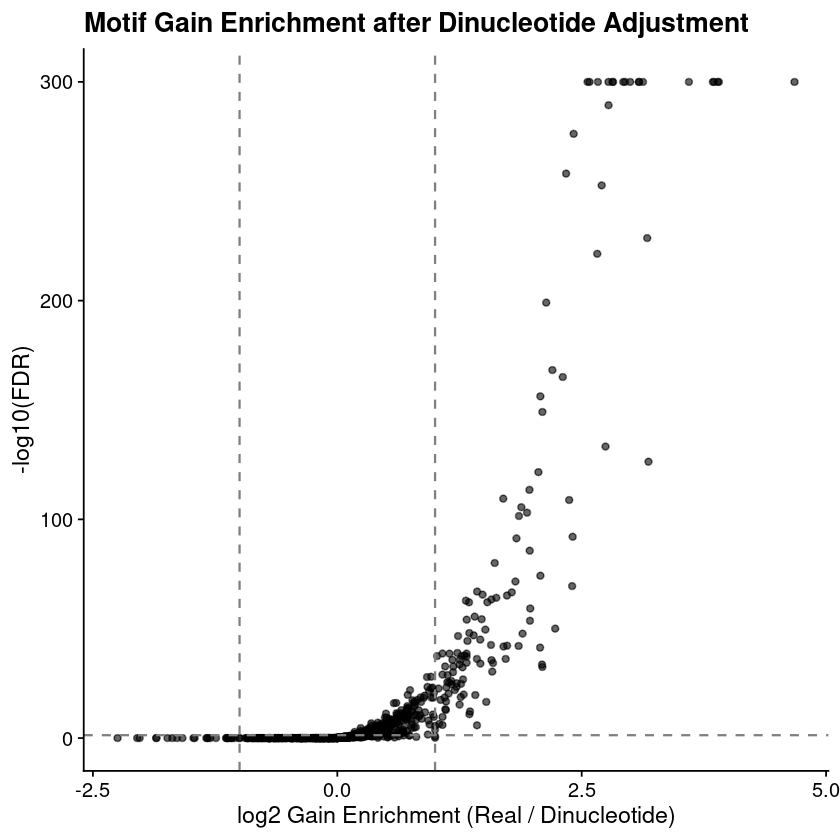

In [13]:
dat_cmp %>%
  filter(!is.na(fdr), !is.na(log2GainEnrich)) %>%
  mutate(fdr_plot = pmax(fdr, 1e-300)) %>%
  ggplot(aes(x = log2GainEnrich, y = -log10(fdr_plot))) +
  geom_point(alpha = 0.6, size = 1.5) +
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "grey50") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "grey50") +
  labs(
    x = "log2 Gain Enrichment (Real / Dinucleotide)",
    y = "-log10(FDR)",
    title = "Motif Gain Enrichment after Dinucleotide Adjustment"
  ) +
  theme_cowplot()

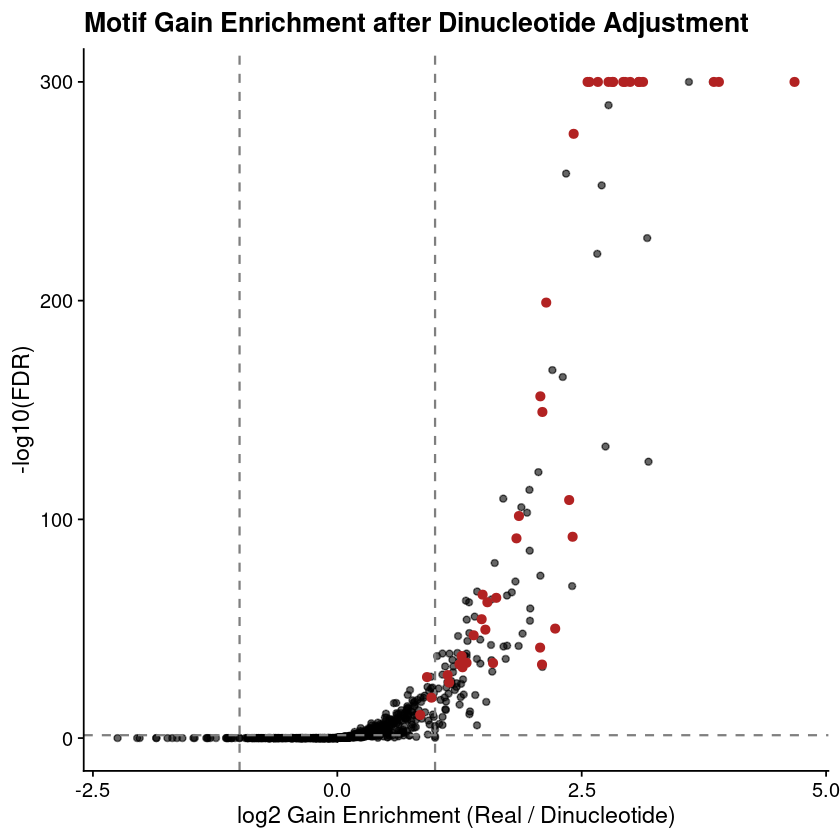

In [17]:
library(tidyverse)

dat_plot <- dat_cmp %>%
  filter(!is.na(fdr), !is.na(log2GainEnrich)) %>%
  mutate(fdr_plot = pmax(fdr, 1e-300))

dat_plot %>%
  ggplot(aes(x = log2GainEnrich, y = -log10(fdr_plot))) +
  geom_point(alpha = 0.6, size = 1.5) +
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "grey50") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "grey50") +
  geom_point(
    data = subset(dat_plot, grepl("JUN|FOS|ATF|CREB", Motif_Name)),
    color = "firebrick", size = 2
  ) +
  labs(
    x = "log2 Gain Enrichment (Real / Dinucleotide)",
    y = "-log10(FDR)",
    title = "Motif Gain Enrichment after Dinucleotide Adjustment"
  ) +
  theme_cowplot()

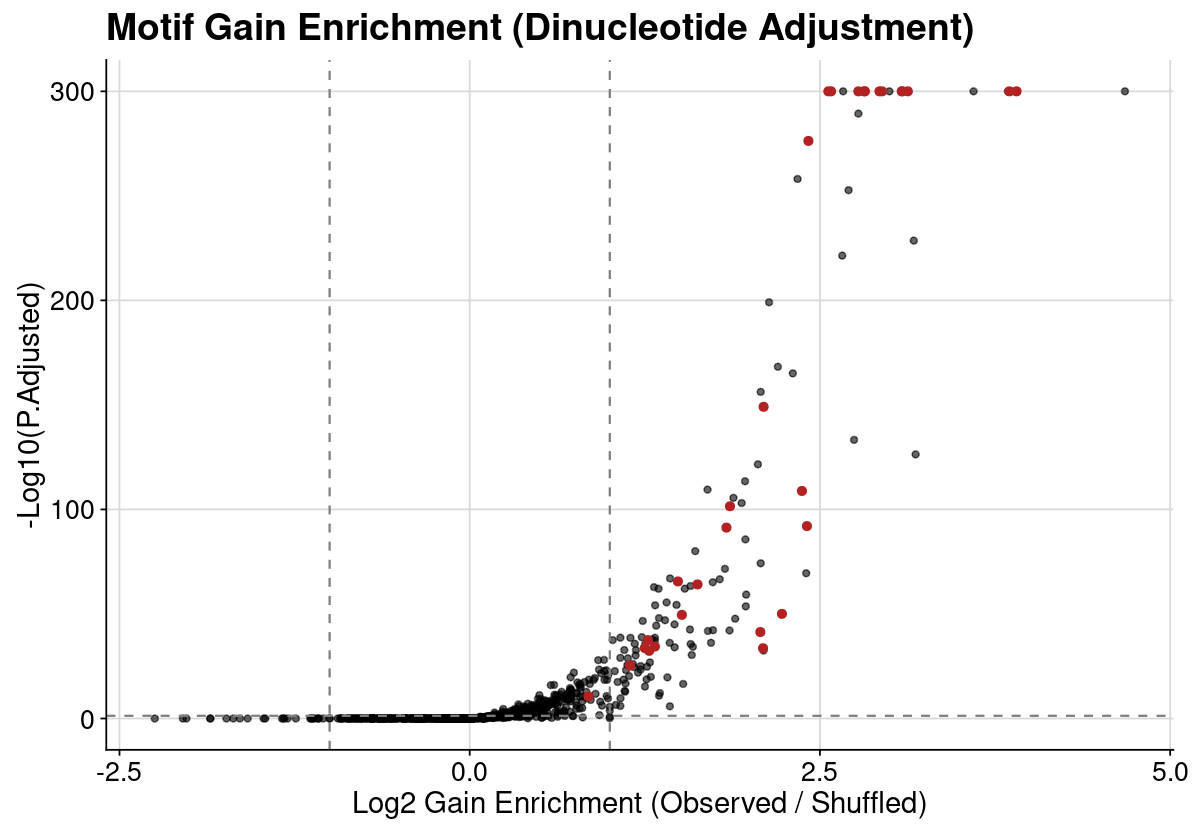

In [30]:
dat_plot <- dat_cmp %>%
  filter(!is.na(fdr), !is.na(log2GainEnrich)) %>%
  mutate(fdr_plot = pmax(fdr, 1e-300))

gpt = dat_plot %>%
  ggplot(aes(x = log2GainEnrich, y = -log10(fdr_plot))) +
  geom_point(alpha = 0.6, size = 1.5) +
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "grey50") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "grey50") +
  geom_point(
    data = subset(dat_plot, grepl("JUN|FOS", Motif_Name)),
    color = "firebrick", size = 2
  ) +
  labs(
    x = "Log2 Gain Enrichment (Observed / Shuffled)",
    y = "-Log10(P.Adjusted)",
    title = "Motif Gain Enrichment (Dinucleotide Adjustment)"
  ) +
  theme_cowplot() +
theme_pub(base_size = 16)

options(repr.plot.height=7, repr.plot.width = 10)
print(gpt)

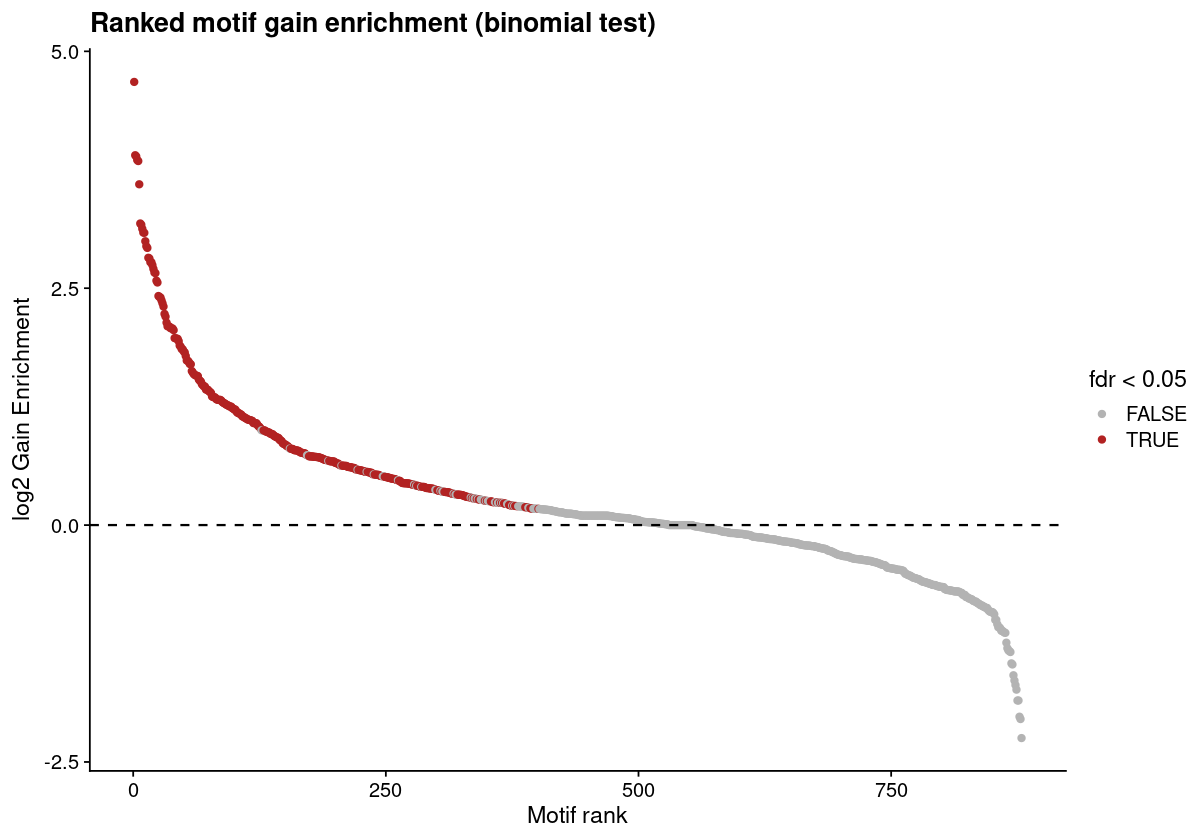

In [26]:
dat_plot <- dat_plot %>%
  arrange(desc(log2GainEnrich)) %>%
  mutate(rank = row_number())

ggplot(dat_plot, aes(rank, log2GainEnrich)) +
  geom_point(aes(color = fdr < 0.05), size = 1.5) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  scale_color_manual(values = c("grey70", "firebrick")) +
  labs(
    x = "Motif rank",
    y = "log2 Gain Enrichment",
    title = "Ranked motif gain enrichment (binomial test)"
  ) +
  theme_cowplot()

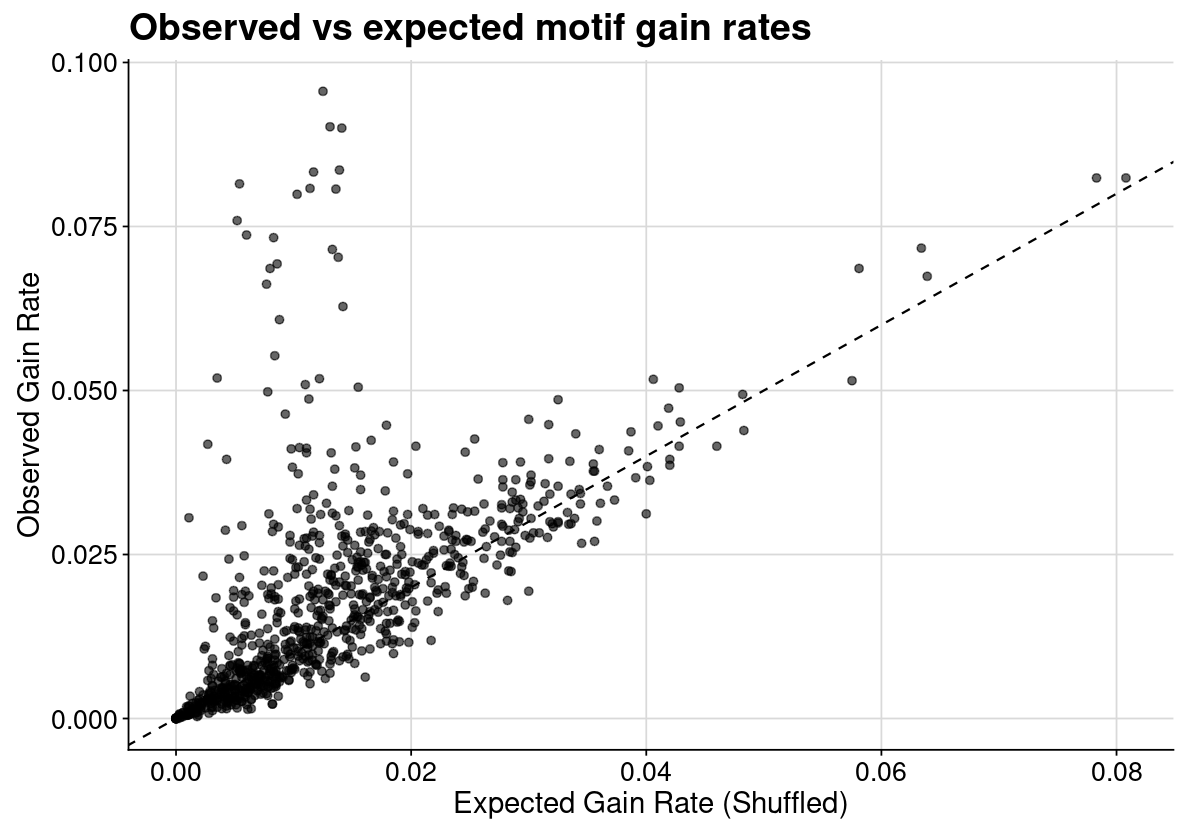

In [35]:
gpt = ggplot(dat_plot, aes(G_dinuc / N, G_real / N)) +
  geom_point(alpha = 0.6) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  labs(
    x = "Expected Gain Rate (Shuffled)",
    y = "Observed Gain Rate",
    title = "Observed vs expected motif gain rates"
  ) +
  theme_cowplot() +
   theme_pub(base_size = 16)

options(repr.plot.height=7, repr.plot.width = 10)
print(gpt)

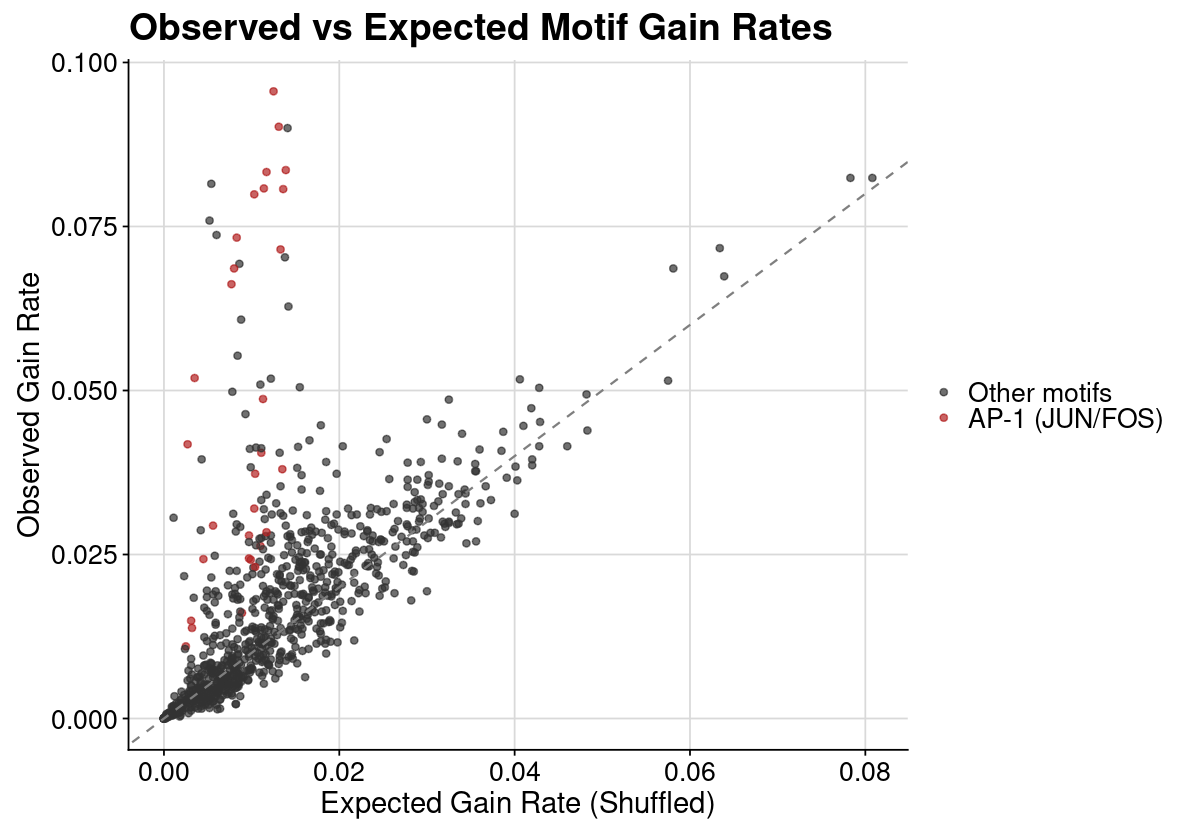

In [40]:
dat <- dat_plot %>%
  mutate(
    is_AP1 = grepl("JUN|FOS", Motif_Name)
  )
gpt = ggplot(dat, aes(G_dinuc / N, G_real / N, color = is_AP1)) +
  geom_point(alpha = 0.7, size = 1.6) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "grey50") +
  scale_color_manual(
    values = c(`FALSE` = "grey20", `TRUE` = "firebrick"),
    labels = c("Other motifs", "AP-1 (JUN/FOS)")
  ) +
  labs(
    x = "Expected Gain Rate (Shuffled)",
    y = "Observed Gain Rate",
    title = "Observed vs Expected Motif Gain Rates",
    color = NULL
  ) +
  theme_cowplot() +
  theme_pub(base_size = 16)
options(repr.plot.height=7, repr.plot.width = 10)
print(gpt)

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”


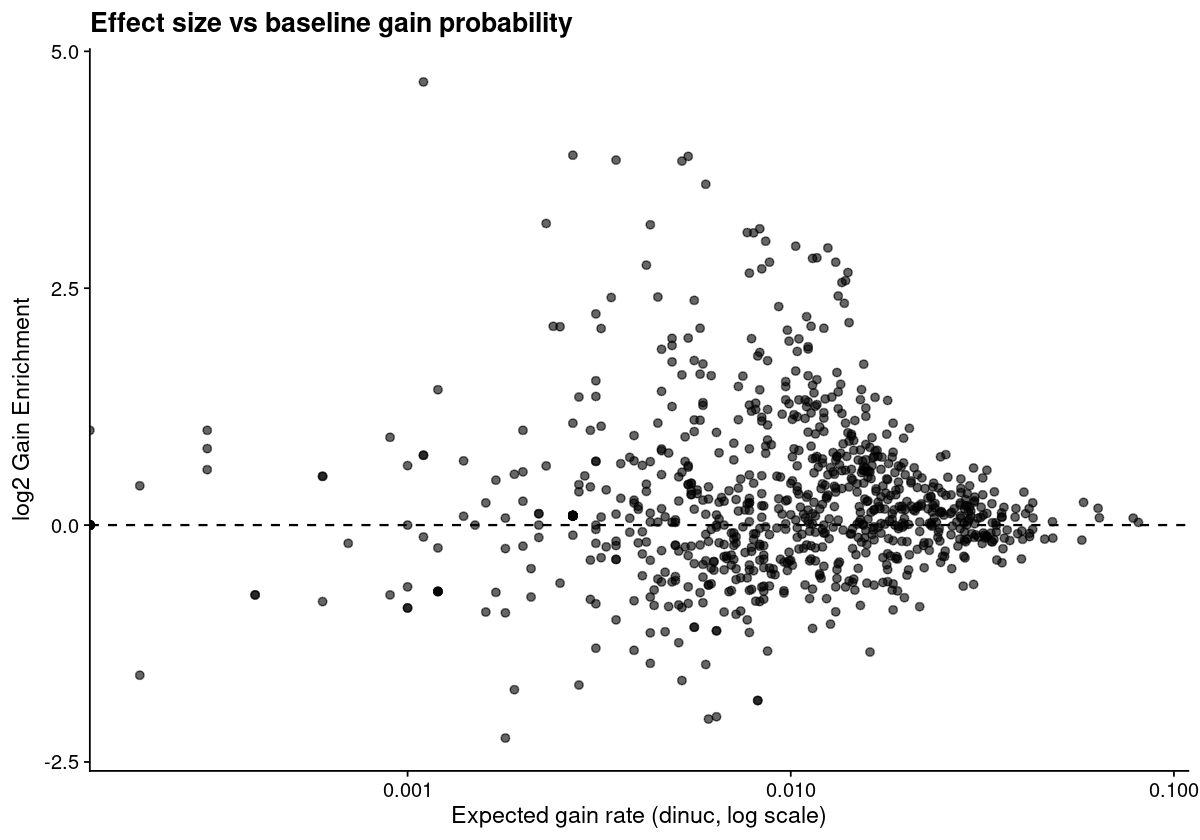

In [28]:
ggplot(dat_plot, aes(G_dinuc / N, log2GainEnrich)) +
  geom_point(alpha = 0.6) +
  scale_x_log10() +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(
    x = "Expected gain rate (dinuc, log scale)",
    y = "log2 Gain Enrichment",
    title = "Effect size vs baseline gain probability"
  ) +
  theme_cowplot()

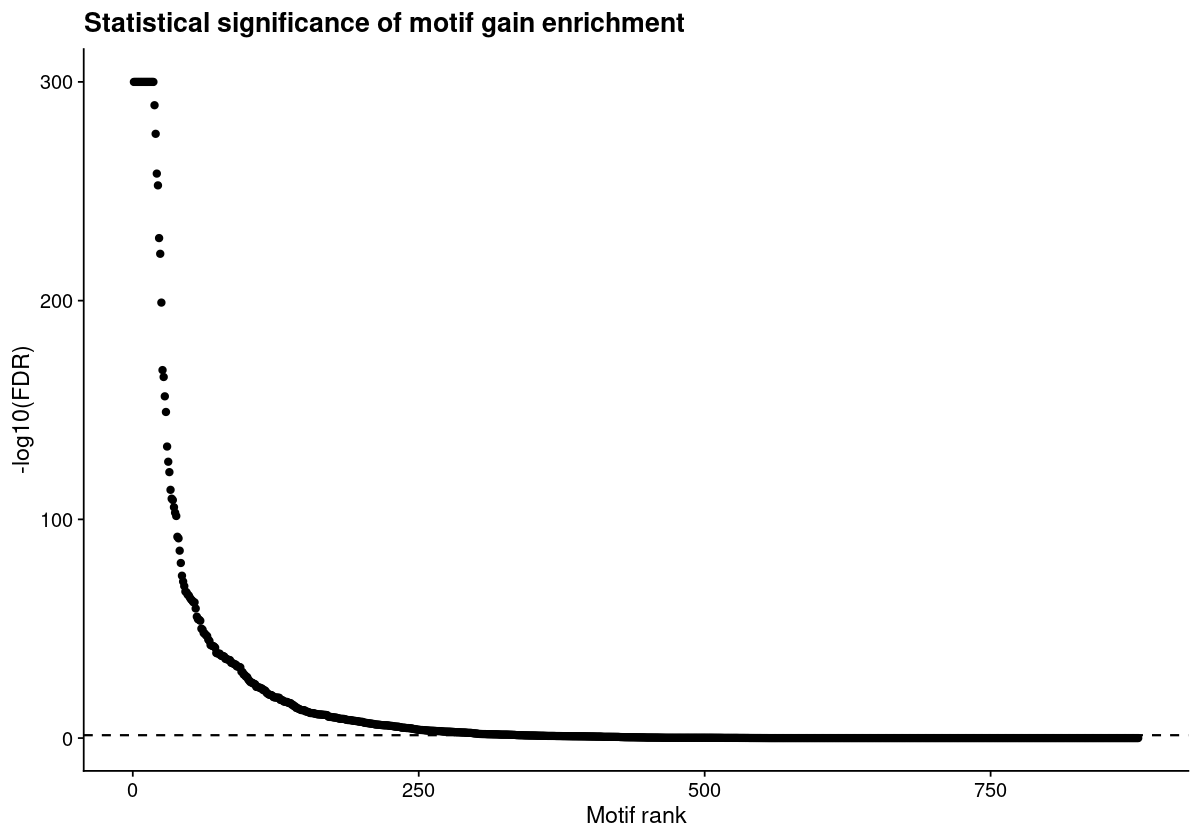

In [29]:
dat_plot %>%
  arrange(fdr) %>%
  mutate(rank = row_number()) %>%
  ggplot(aes(rank, -log10(fdr_plot))) +
  geom_point(size = 1.5) +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed") +
  labs(
    x = "Motif rank",
    y = "-log10(FDR)",
    title = "Statistical significance of motif gain enrichment"
  ) +
  theme_cowplot()
